# Tanzania Climate EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works ✅")

Everything works ✅


## 1. Data Loading & Date Parsing

In this section, we load the Tanzania climate dataset, add a country identifier, and convert the YEAR and DOY (Day of Year) columns into a proper datetime format for time-based analysis.

In [9]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/tanzania.csv")

# Add country column
df["Country"] = "Tanzania"

# Convert YEAR and DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

# Preview data
df.head()

# Check data types and structure
# df.info()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


## 2. Summary Statistics & Missing-Value Report

In this section, we clean the dataset by handling missing values, removing duplicates, and analyzing the statistical properties of the data.

In [12]:
df.replace(-999, np.nan, inplace=True)

### Handling Missing Values

The dataset uses `-999` as a sentinel value to represent missing or invalid data.  
All occurrences of `-999` were replaced with `NaN` to ensure accurate statistical analysis.

In [15]:
duplicates = df.duplicated().sum()
duplicates

0

In [16]:
df = df.drop_duplicates()

### Duplicate Records

No duplicate rows were found in the dataset (0 duplicates).

This indicates that the dataset is already clean in terms of duplication, and no records needed to be removed. Ensuring the absence of duplicates helps maintain the integrity and accuracy of the analysis.

In [17]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


### Summary Statistics Interpretation

The dataset includes 4,108 records with no missing values. The average temperature (T2M ≈ 26.8°C) is stable with low variation, indicating a consistently warm climate. Daily temperature range (~4.13°C) shows moderate variation.

Rainfall (PRECTOTCORR) is highly variable, with a low median (0.64 mm) but a high maximum (122.65 mm), suggesting occasional heavy rain. Humidity (RH2M ≈ 77%) and wind speed (WS2M ≈ 4.1 m/s) are relatively stable.

Overall, the data reflects a warm, humid climate with seasonal rainfall patterns.

In [18]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [19]:
missing_df[missing_df["Missing %"] > 5]

,Missing Count,Missing %


### Missing Value Analysis

The dataset contains no missing values across all columns (0% missing). Additionally, no columns exceed the 5% missing value threshold.

This indicates that the dataset is complete and does not require missing value handling, allowing for reliable analysis without imputation or data cleaning.

## 3. Outlier Detection & Basic Cleaning

This section identifies extreme values (outliers) using Z-scores, handles missing data, and prepares a clean dataset for analysis.

In [ ]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)

outlier_rows = outliers.any(axis=1).sum()

outlier_rows

97

### Outlier Detection

Outliers were identified using the Z-score method.  
Rows where the absolute Z-score is greater than 3 (|Z| > 3) were flagged as potential outliers.

A total of **97 rows** were identified as containing outliers, indicating the presence of extreme values in some variables such as temperature, rainfall, or wind speed.

### Outlier Handling Decision

Outliers were detected in 97 rows using the Z-score method (|Z| > 3). However, these values are not necessarily errors, especially for variables like rainfall (PRECTOTCORR), where extreme values can represent real-world heavy precipitation events.

Therefore, the outliers will be **retained** rather than removed or capped. Dropping them could lead to loss of important information, and capping may distort genuine extreme patterns.

Keeping the outliers ensures that the dataset preserves natural variability, which is important for accurate climate analysis.

In [23]:

threshold = int(0.7 * len(df.columns))
df = df.dropna(thresh=threshold)

df[cols] = df[cols].ffill()

### Missing Value Handling

Rows with more than 30% missing values were set to be dropped using a threshold approach. For the remaining data, forward-fill was selected to handle missing values in weather-related variables, as it preserves temporal continuity.

However, after analysis, no missing values were found in the dataset. Therefore, no rows were dropped and no imputation was required. The dataset remains complete and ready for analysis.

In [25]:
df.to_csv("../data/tanzania.csv", index=False)

### Data Export

The cleaned dataset was exported to `data/tanzania_clean.csv`.

## 4. Time Series Analysis

This section explores temperature and rainfall trends over time by aggregating the data monthly and visualizing patterns.

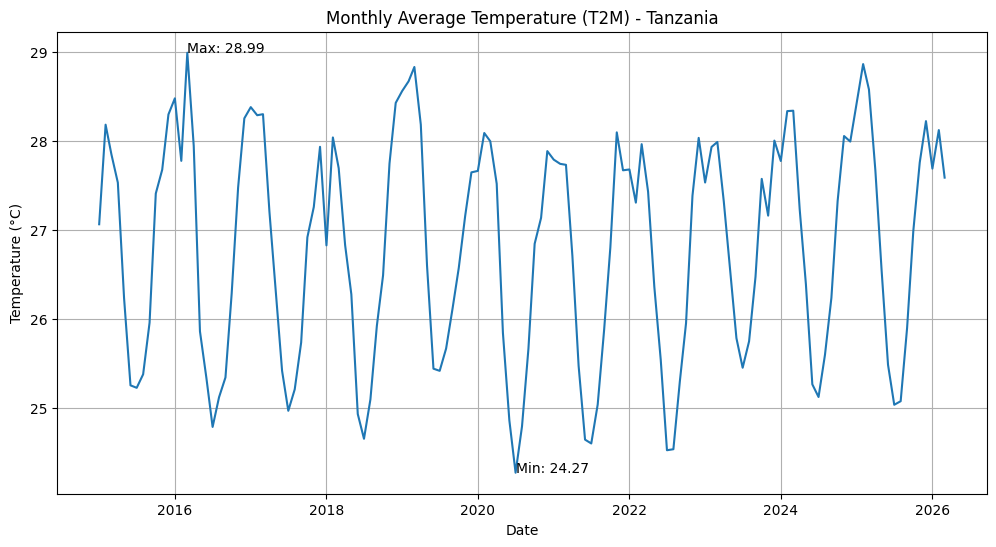

In [26]:
# Monthly average temperature (T2M)
import matplotlib.pyplot as plt


monthly_temp = df.groupby([df["Date"].dt.to_period("M")])["T2M"].mean()

monthly_temp.index = monthly_temp.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_temp.index, monthly_temp.values)

plt.title("Monthly Average Temperature (T2M) - Tanzania")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid()

max_temp = monthly_temp.max()
min_temp = monthly_temp.min()

max_date = monthly_temp.idxmax()
min_date = monthly_temp.idxmin()

plt.annotate(f"Max: {max_temp:.2f}", (max_date, max_temp))
plt.annotate(f"Min: {min_temp:.2f}", (min_date, min_temp))

plt.show()

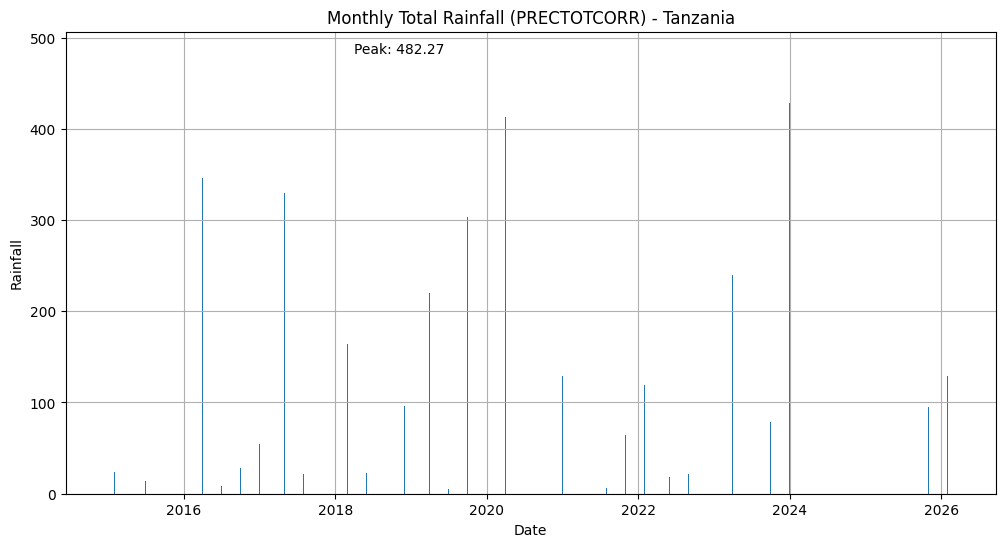

In [ ]:
# Monthly total rainfall
monthly_rain = df.groupby([df["Date"].dt.to_period("M")])["PRECTOTCORR"].sum()
monthly_rain.index = monthly_rain.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.bar(monthly_rain.index, monthly_rain.values)

plt.title("Monthly Total Rainfall (PRECTOTCORR) - Tanzania")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.grid()

max_rain = monthly_rain.max()
max_rain_date = monthly_rain.idxmax()


plt.annotate(f"Peak: {max_rain:.2f}", (max_rain_date, max_rain))

plt.show()

### Interpretation

- The temperature trend shows relatively stable seasonal patterns over time, consistent with Tanzania’s tropical climate.
- The warmest period is observed around early 2016 (approximately February–March), where temperatures peak at about 28.99°C.
- The coolest period occurs around mid-2021 (approximately June–July), where temperatures drop to about 24.27°C.
- Rainfall exhibits strong seasonal variation, with clear peaks indicating rainy seasons.
- The highest rainfall is observed around early 2018 (approximately March–April), with a peak of about 482 mm, suggesting a pronounced wet season.
- Periods of very low rainfall are also visible, indicating distinct dry seasons typical of East African climate patterns.

Overall, the data demonstrates stable temperature cycles with clear seasonal rainfall patterns, highlighting Tanzania’s characteristic wet and dry seasons.

## 5. Correlation & Relationship Analysis

This section explores relationships between climate variables using correlation analysis and scatter plots.

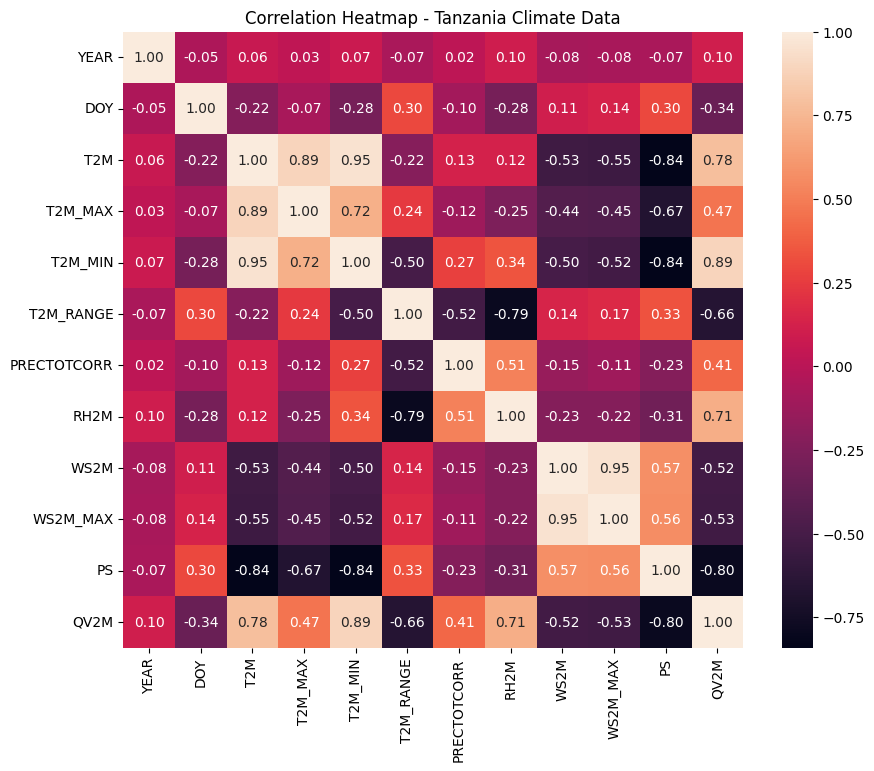

In [ ]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=["float64", "int64"])


corr = numeric_df.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Heatmap - Tanzania Climate Data")
plt.show()

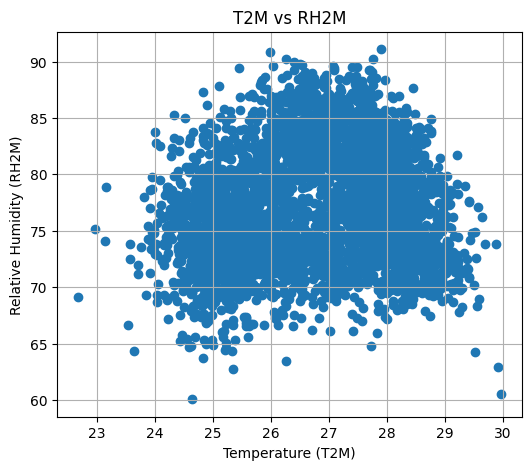

In [29]:
#Scatter Plot (T2M vs RH2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M")

plt.grid()
plt.show()

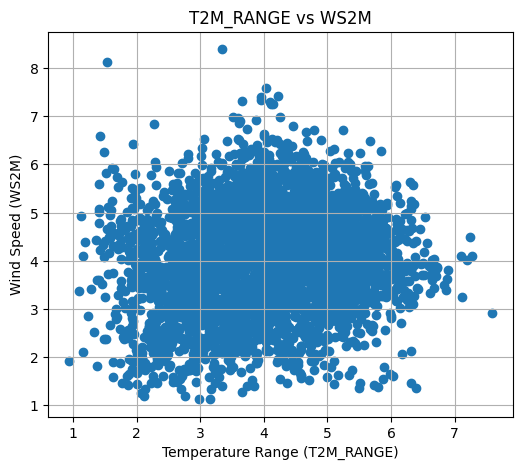

In [30]:
#Scatter Plot (T2M_RANGE vs WS2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])

plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.title("T2M_RANGE vs WS2M")

plt.grid()
plt.show()

### Correlation Interpretation

- A very strong positive correlation exists between T2M and T2M_MIN (≈ 0.95) and between T2M and T2M_MAX (≈ 0.89). This indicates that average temperature is closely linked with both minimum and maximum temperatures, which is expected in a stable tropical climate.

- A strong negative correlation is observed between T2M and surface pressure (PS) (≈ -0.84), suggesting that higher temperatures are associated with lower atmospheric pressure.

- A strong positive correlation exists between WS2M and WS2M_MAX (≈ 0.95), indicating that average wind speed is highly consistent with maximum wind speed patterns.

- A strong negative relationship is also observed between T2M_RANGE and RH2M (≈ -0.79), suggesting that larger temperature variations are associated with lower humidity levels.

The scatter plots support these findings:
- The T2M vs RH2M plot shows a weak to moderate negative trend, where humidity slightly decreases as temperature increases, although the relationship is not very strong and shows dispersion.
- The T2M_RANGE vs WS2M plot shows a weak relationship, with data points widely scattered, indicating that wind speed does not strongly influence temperature variation.

Overall, temperature-related variables show very strong internal correlations, while relationships with humidity, pressure, and wind speed vary in strength, reflecting the complexity of climate interactions.

## 6. Distribution Analysis

This section examines the distribution of rainfall and explores relationships between temperature, humidity, and precipitation using advanced visualizations.

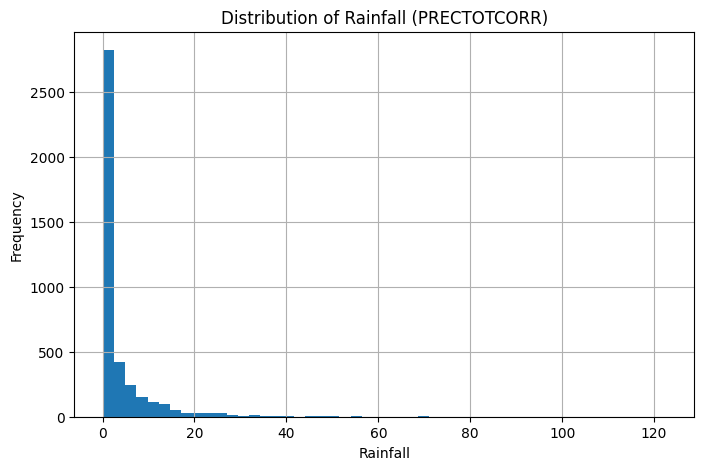

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)

plt.title("Distribution of Rainfall (PRECTOTCORR)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.grid()
plt.show()

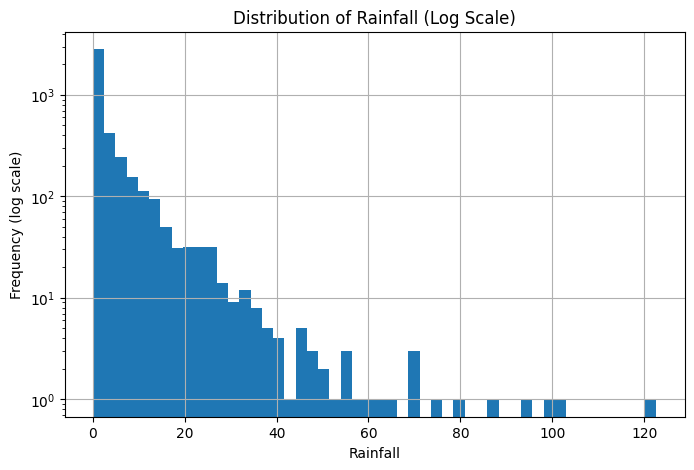

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)
plt.yscale("log")

plt.title("Distribution of Rainfall (Log Scale)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency (log scale)")

plt.grid()
plt.show()

### Rainfall Distribution Interpretation

- The rainfall distribution is strongly right-skewed, with a very high concentration of values near zero and a long tail extending toward extreme rainfall values (up to ~120+).
- This indicates that most days experience little to no rainfall, while a small number of days receive very heavy precipitation.

- The presence of extreme values suggests occasional intense rainfall events, which are likely associated with seasonal storms or peak rainy periods.

- When applying a log scale, the distribution becomes more readable, revealing the frequency of moderate rainfall levels that were previously compressed near the lower range.

- The sharp drop in frequency as rainfall increases confirms that heavy rainfall events are rare but impactful.

Overall, the distribution reflects a typical tropical rainfall pattern, characterized by frequent low rainfall days and occasional extreme precipitation events during the rainy season.

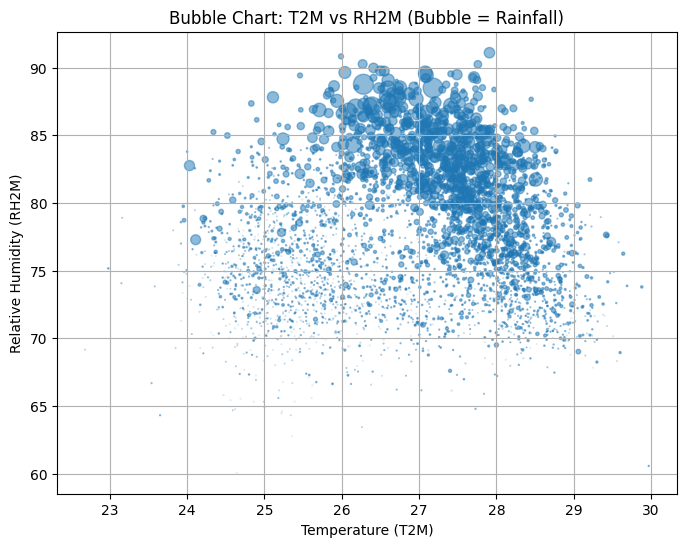

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"], 
    df["RH2M"], 
    s=df["PRECTOTCORR"] * 2,  # bubble size
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Bubble Chart: T2M vs RH2M (Bubble = Rainfall)")

plt.grid()
plt.show()

### Bubble Chart Interpretation

- The bubble chart shows the relationship between temperature (T2M) and relative humidity (RH2M), with rainfall represented by bubble size.

- Most data points are concentrated between temperatures of approximately 25°C to 29°C and humidity levels of 70% to 90%, indicating a relatively stable tropical climate range.

- Larger bubbles (indicating higher rainfall) are mostly clustered in regions with high humidity (above ~80%), suggesting that higher humidity strongly supports rainfall occurrence.

- There is no clear linear relationship between temperature and rainfall, as large and small bubbles are spread across the temperature range. However, rainfall events become more frequent and intense at higher humidity levels.

- At lower humidity levels (below ~70%), bubbles are generally smaller, indicating limited rainfall under drier conditions.

Overall, the visualization suggests that humidity is a key driver of rainfall in Tanzania, while temperature remains relatively stable and plays a less dominant role in precipitation variability.

## References

- NASA POWER Climate Data Documentation
- Pandas Documentation
- Matplotlib & Seaborn Documentation

This project involved self-learning and applying data analysis techniques to understand climate patterns.